In [29]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
from scipy.linalg import orthogonal_procrustes

# ===================================================================
# A) Configuration
# ===================================================================
MODEL_DIR = "../data" 
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

K_list = [1, 2, 3]
N_REPETITIONS = 100

print(f"Calculating standard errors (aligned & sign-fixed) for K={K_list} from {N_REPETITIONS} repetitions.")

# ===================================================================
# B) Helper: sign fixing
# ===================================================================
def fix_signs(a, theta):
    """
    Ensures consistency by forcing the first item's loading on each factor to be positive.
    If negative, flips the entire dimension for both a and theta.
    """
    for dim in range(a.shape[1]):
        if a[0, dim] < 0:  # check first item's loading
            a[:, dim] *= -1
            theta[:, dim] *= -1
    return a, theta

# ===================================================================
# C) Main Calculation Loop
# ===================================================================
summary_results = []

for k in K_list:
    print(f"\n--- Processing K = {k} ---")
    
    theta_reps, a_reps, b_reps = [], [], []
    
    # --- Load repetitions ---
    pbar = tqdm(range(N_REPETITIONS), desc=f"  Loading reps for K={k}")
    for r in pbar:
        model_path = os.path.join(MODEL_DIR, f"mirt_model_k{k}_rep{r}.pt")
        try:
            state = torch.load(model_path, map_location="cpu")
            theta_reps.append(state['theta'].numpy())
            a_reps.append(state['a'].numpy())
            b_reps.append(state['b'].numpy())
        except FileNotFoundError:
            print(f"⚠️ Warning: Skipping missing file: {model_path}")
            continue
    
    if not theta_reps:
        print(f"❌ No model files found for K={k}. Skipping.")
        continue
    
    # --- Reference solution ---
    theta_ref = theta_reps[0]
    a_ref = a_reps[0]
    a_ref, theta_ref = fix_signs(a_ref, theta_ref)  # ensure stable reference
    
    aligned_theta, aligned_a, aligned_b = [], [], []
    
    for t, a, b in zip(theta_reps, a_reps, b_reps):
        if k > 1:
            R, _ = orthogonal_procrustes(a, a_ref)
            a_aligned = a @ R
            t_aligned = t @ R
        else:
            a_aligned, t_aligned = a, t
        
        # --- Fix signs for comparability ---
        a_aligned, t_aligned = fix_signs(a_aligned, t_aligned)
        
        aligned_theta.append(t_aligned)
        aligned_a.append(a_aligned)
        aligned_b.append(b)
    
    # --- Stack aligned arrays ---
    theta_stack = np.stack(aligned_theta, axis=0)
    a_stack = np.stack(aligned_a, axis=0)
    b_stack = np.stack(aligned_b, axis=0)
    
    # --- Standard Errors ---
    theta_se = np.std(theta_stack, axis=0, ddof=1)
    a_se = np.std(a_stack, axis=0, ddof=1)
    b_se = np.std(b_stack, axis=0, ddof=1)
    
    # --- Save full arrays ---
    se_output_path = os.path.join(OUTPUT_DIR, f"standard_errors_k{k}.npz")
    np.savez_compressed(
        se_output_path,
        theta_se=theta_se,
        a_se=a_se,
        b_se=b_se
    )
    print(f"  ✅ Saved SE arrays (aligned & sign-fixed) to: {se_output_path}")
    
    # --- Summary ---
    summary_results.append({
        'K': k,
        'avg_theta_se': np.mean(theta_se),
        'avg_a_se': np.mean(a_se),
        'avg_b_se': np.mean(b_se),
        'num_reps_found': len(theta_reps)
    })

# ===================================================================
# D) Save Summary
# ===================================================================
summary_df = pd.DataFrame(summary_results)
summary_csv_path = os.path.join(OUTPUT_DIR, "standard_errors_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

print(f"\n✅ All calculations complete. Summary saved to: {summary_csv_path}")
print("\n--- Summary of Average Standard Errors (Aligned + Sign-Fixed) ---")
print(summary_df)


Calculating standard errors (aligned & sign-fixed) for K=[1, 2, 3] from 100 repetitions.

--- Processing K = 1 ---


  Loading reps for K=1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 16.29it/s]


  ✅ Saved SE arrays (aligned & sign-fixed) to: ../output/standard_errors_k1.npz

--- Processing K = 2 ---


  Loading reps for K=2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 14.89it/s]


  ✅ Saved SE arrays (aligned & sign-fixed) to: ../output/standard_errors_k2.npz

--- Processing K = 3 ---


  Loading reps for K=3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.18it/s]


  ✅ Saved SE arrays (aligned & sign-fixed) to: ../output/standard_errors_k3.npz

✅ All calculations complete. Summary saved to: ../output/standard_errors_summary.csv

--- Summary of Average Standard Errors (Aligned + Sign-Fixed) ---
   K  avg_theta_se  avg_a_se  avg_b_se  num_reps_found
0  1      1.551981  0.314131  0.200745             100
1  2      1.554289  0.383976  0.264135             100
2  3      1.277670  0.348319  0.264824             100


In [30]:
import pandas as pd
import os

DATA_DIR = "../data"

results_df = pd.read_csv(os.path.join(DATA_DIR, "mirt_comparison_repeated.csv"))
results_df.sort_values(by=["K", "Test AUC"], ascending=False).groupby("K").head(1)

,Repetition,K,Test AUC,AIC,BIC,Num Params,LogLikelihood
0,0,30,0.892782,7211868.50,3.965619e+07,2445562,-1160372.250
7,1,11,0.893511,4456108.00,1.701371e+07,946557,-1281497.000
11,2,10,0.893778,4375323.00,1.588626e+07,867662,-1319999.500
1,0,9,0.893633,4170361.75,1.463463e+07,788767,-1296413.875
52,3,8,0.893422,4076280.00,1.349388e+07,709872,-1328268.000
5,0,7,0.893155,3936700.50,1.230763e+07,630977,-1337373.250
50,3,6,0.892801,3864888.50,1.118915e+07,552082,-1380362.250
21,0,5,0.891522,3798209.25,1.007580e+07,473187,-1425917.625
20,0,4,0.891534,3741453.50,8.972373e+06,394292,-1476434.750
184,47,3,0.891510,3679949.50,7.864200e+06,315397,-1524577.750


In [31]:
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

In [34]:
import numpy as np
import os
import torch
from load_params import load_and_rotate

k = 1; r= 93

theta_se = np.load(f"../output/standard_errors_k{k}.npz")['theta_se']
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation=None)

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Loading from Cache ---
Loaded cached theta shape: (183, 1)
Loaded cached a shape: (78712, 1)
Loaded cached b shape: (78712,)



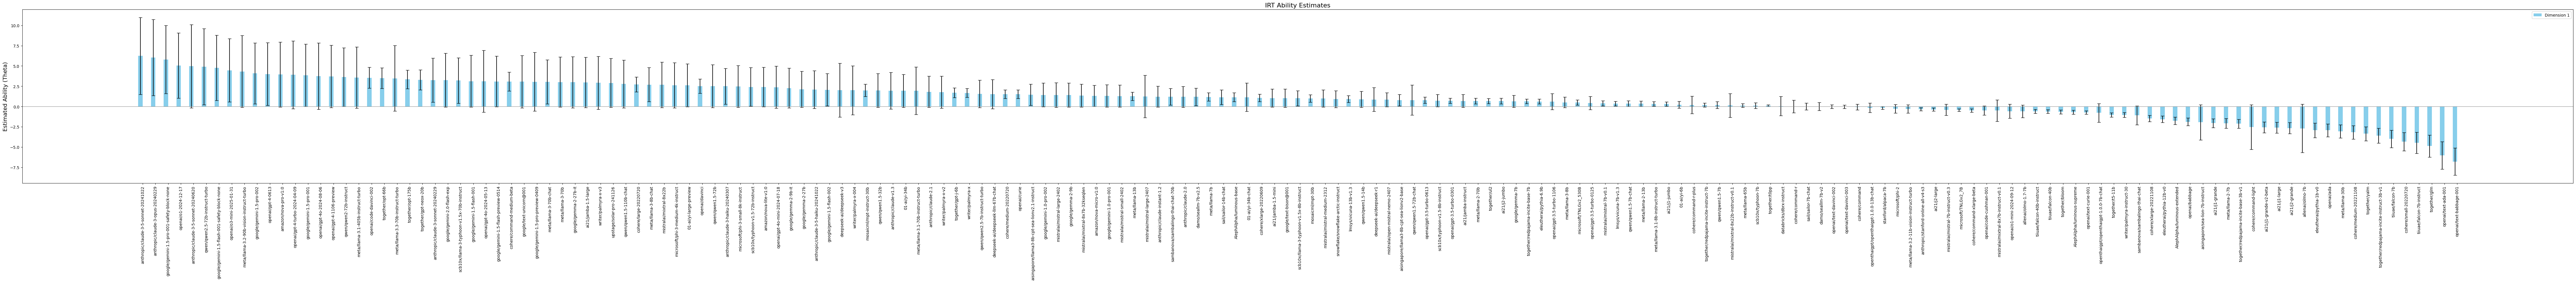

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = theta_df.sort_values('ability_dim1', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['ability_dim1']
# ability2 = df_sorted['ability_dim2']
# Calculate the 95% confidence interval size (1.96 * SE)
ci1 = df_sorted['se_dim1']
# ci2 = df_sorted['se_dim2']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Dimension 1', 
                yerr=ci1, capsize=4, color='skyblue')

# rects2 = ax.bar(x + width/2, ability2, width, label='Dimension 2', 
#                 yerr=ci2, capsize=4, color='salmon')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('IRT Ability Estimates', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_k{k}.pdf', bbox_inches='tight')

plt.show()

In [36]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_score_baseline = resmat.mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                                               raw_accuracy
request.model                                              
google/gemini-1.5-pro-001-safety-block-none        0.873019
anthropic/claude-3-5-sonnet-20241022               0.869802
anthropic/claude-3-5-sonnet-20240620               0.855008
anthropic/claude-3-opus-20240229                   0.831202
openai/o1-2024-12-17                               0.827482
qwen/qwen2.5-72b-instruct-turbo                    0.821147
google/gemini-1.5-flash-001-safety-block-none      0.818255
google/gemini-1.5-pro-002                          0.808939
amazon/nova-pro-v1:0                               0.806270
google/gemini-1.5-pro-preview-0409                 0.805339


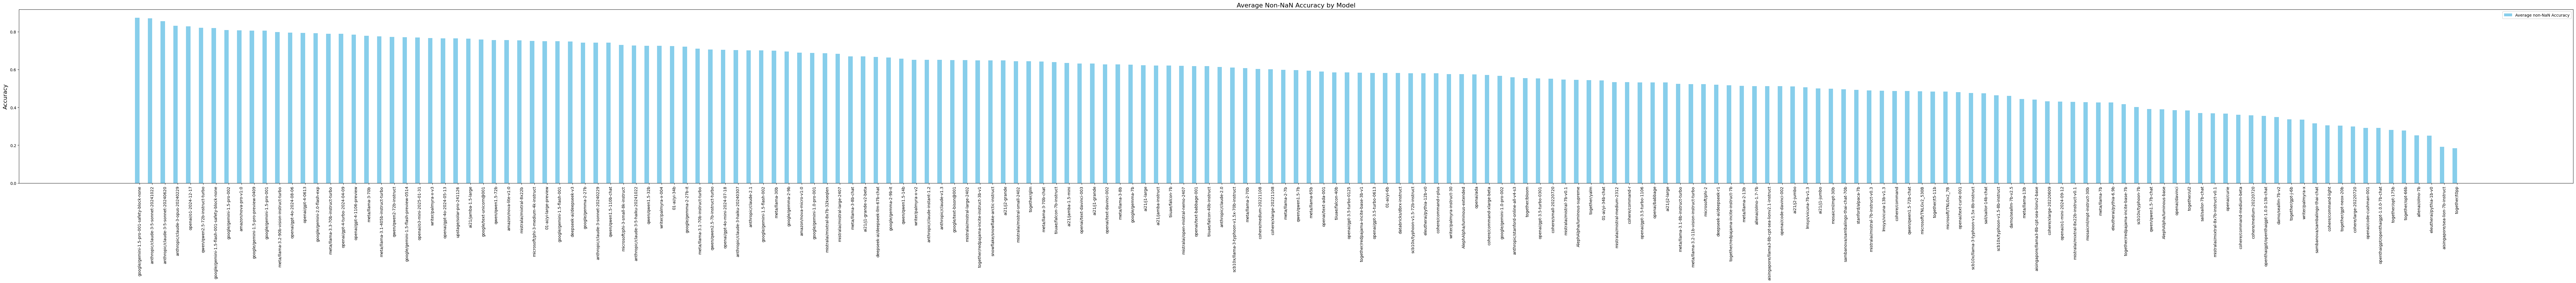

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = baseline_df.sort_values('raw_accuracy', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['raw_accuracy']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Average non-NaN Accuracy', 
                capsize=4, color='skyblue')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Average Non-NaN Accuracy by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_average_non_nan.pdf', bbox_inches='tight')

plt.show()

In [38]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_nan_score_baseline = resmat.fillna(0).mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_nan_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                           raw_accuracy
request.model                          
openai/gpt-3.5-turbo-0613      0.565136
meta/llama-2-70b               0.550539
meta/llama-2-7b                0.543284
mistralai/mistral-7b-v0.1      0.496646
ai21/j2-grande                 0.493368
openai/text-davinci-003        0.480981
openai/text-davinci-002        0.477704
meta/llama-30b                 0.473397
ai21/j1-grande-v2-beta         0.467896
meta/llama-2-13b               0.465977


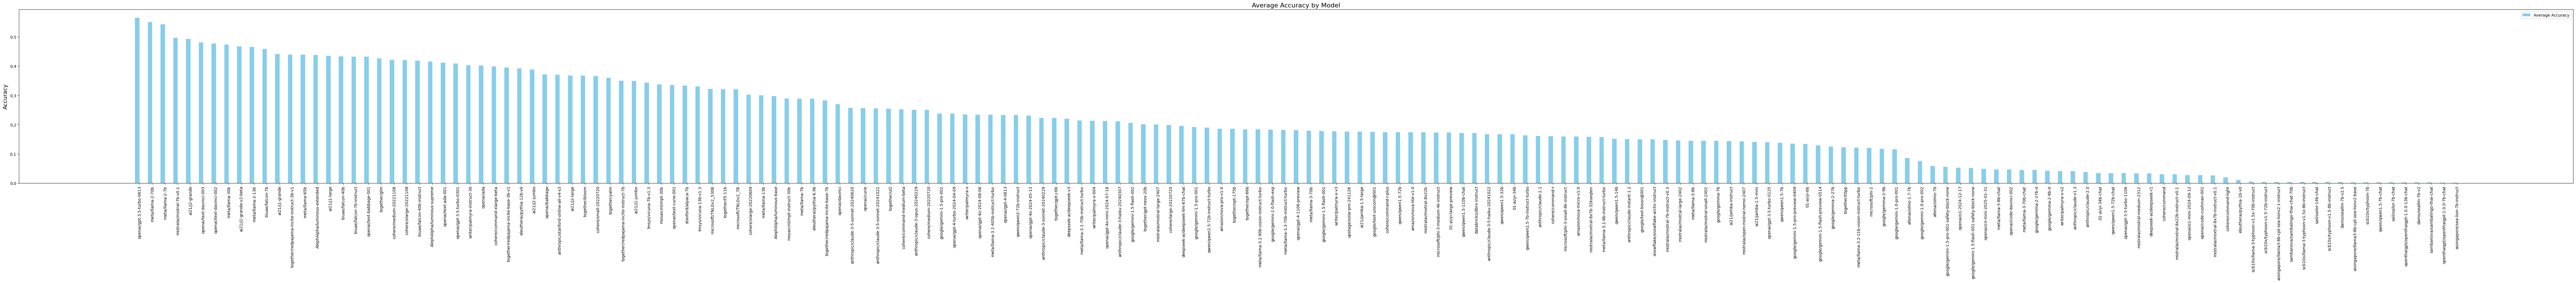

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = baseline_df.sort_values('raw_accuracy', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['raw_accuracy']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Average Accuracy', 
                capsize=4, color='skyblue')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Average Accuracy by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_average_nan.pdf', bbox_inches='tight')

plt.show()

In [60]:
import numpy as np
import os
from load_params import load_and_rotate

k = 2; r = 87

theta_se = np.load(f"../output/standard_errors_k{k}.npz")['theta_se']
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation='oblimax')

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0],
    'ability_dim2': theta[:, 1],
    'se_dim2':      theta_se[:, 1]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Cache not found, computing rotation ---
--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 2])
Original 'a' matrix shape: torch.Size([78712, 2])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 2)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 2)

--- Saving to Cache ---
Cached results saved to output



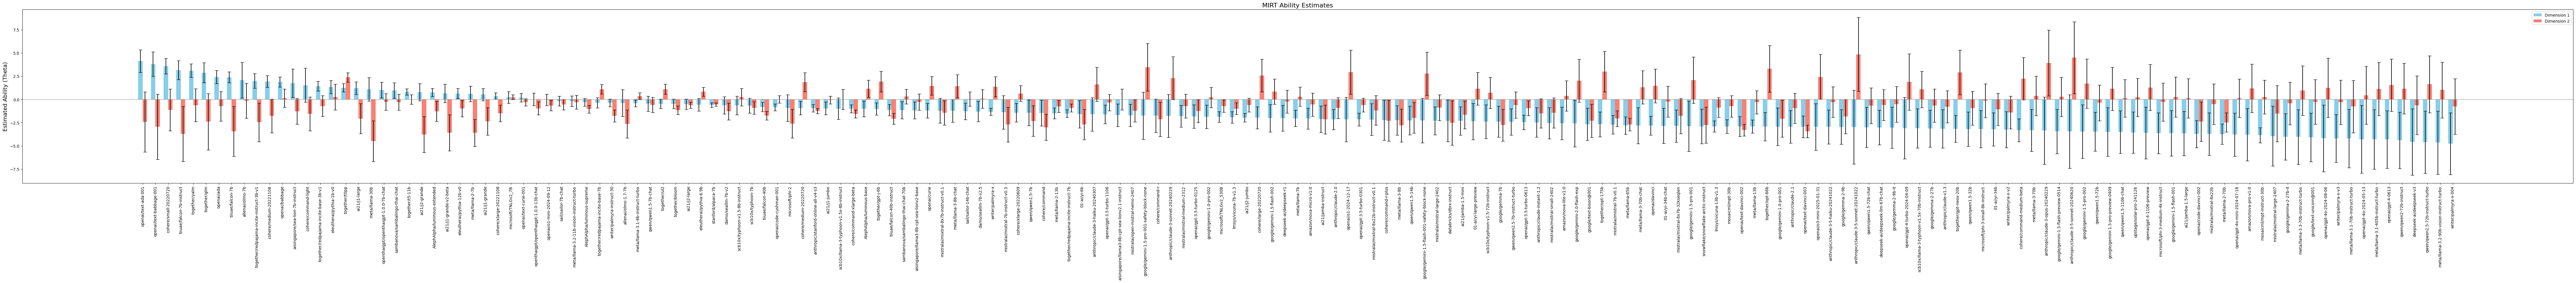

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = theta_df.sort_values('ability_dim1', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['ability_dim1']
ability2 = df_sorted['ability_dim2']
# Calculate the 95% confidence interval size (1.96 * SE)
ci1 = df_sorted['se_dim1']
ci2 = df_sorted['se_dim2']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Dimension 1', 
                yerr=ci1, capsize=4, color='skyblue')

rects2 = ax.bar(x + width/2, ability2, width, label='Dimension 2', 
                yerr=ci2, capsize=4, color='salmon')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_k{k}.pdf', bbox_inches='tight')

plt.show()

In [62]:
import pandas as pd
import numpy as np

# Assume 'theta_df' is your DataFrame with abilities and standard errors

# Select two models to compare
model_a_name = 'anthropic/claude-3-haiku-20240307'  # Replace with the actual model name from your index
model_b_name = 'openai/gpt-3.5-turbo-1106' # Replace with the other model name

# Get the values for Dimension 1
ability_a = theta_df.loc[model_a_name, 'ability_dim1']
se_a = theta_df.loc[model_a_name, 'se_dim1']

ability_b = theta_df.loc[model_b_name, 'ability_dim1']
se_b = theta_df.loc[model_b_name, 'se_dim1']

# Calculate the z-statistic
se_difference = np.sqrt(se_a**2 + se_b**2)
z_statistic = (ability_a - ability_b) / se_difference

# Interpret the result
print(f"Comparing {model_a_name} and {model_b_name} on Dimension 1:")
print(f"  Ability Difference: {ability_a - ability_b:.4f}")
print(f"  Z-Statistic: {z_statistic:.4f}")

if abs(z_statistic) > 1.96:
    print("  Conclusion: The difference is statistically significant (p < 0.05).")
else:
    print("  Conclusion: The difference is NOT statistically significant.")

Comparing anthropic/claude-3-haiku-20240307 and openai/gpt-3.5-turbo-1106 on Dimension 1:
  Ability Difference: 0.0048
  Z-Statistic: 0.0023
  Conclusion: The difference is NOT statistically significant.


In [64]:
import pandas as pd
import numpy as np
from scipy.stats import norm

def create_performance_tiers(df, ability_col, se_col, alpha=0.05):
    """
    Groups models into performance tiers based on statistical significance.

    Args:
        df (pd.DataFrame): DataFrame containing model performance data.
        ability_col (str): The name of the column with ability scores (theta).
        se_col (str): The name of the column with standard errors.
        alpha (float): The significance level for the z-test (e.g., 0.05 for 95% confidence).

    Returns:
        pd.DataFrame: The original DataFrame with an added 'tier' column.
    """
    # --- 1. Sort models by ability in descending order ---
    df_sorted = df.sort_values(by=ability_col, ascending=False).copy()

    # --- 2. Initialize variables ---
    if df_sorted.empty:
        return df_sorted
    
    # Calculate the critical z-value from the significance level
    critical_z = norm.ppf(1 - alpha / 2) # e.g., for alpha=0.05, this is ~1.96
    
    tiers = [0] * len(df_sorted)
    current_tier = 1
    anchor_idx = 0  # The index of the top model in the current tier
    
    # The first model is always in Tier 1
    tiers[0] = current_tier

    # --- 3. Iterate through models to assign tiers ---
    for i in range(1, len(df_sorted)):
        # Get anchor model's data (top of the current tier)
        anchor_ability = df_sorted.iloc[anchor_idx][ability_col]
        anchor_se = df_sorted.iloc[anchor_idx][se_col]

        # Get current model's data
        current_ability = df_sorted.iloc[i][ability_col]
        current_se = df_sorted.iloc[i][se_col]
        
        # --- 4. Perform the Z-test against the anchor ---
        se_difference = np.sqrt(anchor_se**2 + current_se**2)
        # Avoid division by zero if SEs are zero
        if se_difference > 0:
            z_statistic = (anchor_ability - current_ability) / se_difference
        else:
            z_statistic = np.inf if anchor_ability != current_ability else 0
        
        # --- 5. Assign to a tier ---
        if abs(z_statistic) <= critical_z:
            # Difference is NOT significant, so it's in the same tier
            tiers[i] = current_tier
        else:
            # Difference IS significant, so it starts a new tier
            current_tier += 1
            tiers[i] = current_tier
            # This model is now the anchor for the new tier
            anchor_idx = i
            
    df_sorted['tier'] = tiers
    return df_sorted

# --- Call the function to create the tiers ---
tiered_results = create_performance_tiers(
    df=theta_df, 
    ability_col='ability_dim1', 
    se_col='se_dim1'
)

print("--- Models with Assigned Performance Tiers ---")
print(tiered_results)

print("\n--- Final Tiers Grouped for Clarity ---")
for tier_num, group in tiered_results.groupby('tier'):
    print(f"Tier {tier_num}: {list(group.index)}")

--- Models with Assigned Performance Tiers ---
                                          ability_dim1   se_dim1  \
request.model                                                      
openai/text-ada-001                           4.120054  1.223674   
openai/text-babbage-001                       3.800174  1.317743   
cohere/small-20220720                         3.570939  0.831581   
tiiuae/falcon-7b-instruct                     3.141142  1.022430   
together/yalm                                 3.098743  0.731882   
...                                                ...       ...   
qwen/qwen2-72b-instruct                      -4.400535  3.035323   
deepseek-ai/deepseek-v3                      -4.593536  3.567620   
qwen/qwen2.5-72b-instruct-turbo              -4.622987  3.358837   
meta/llama-3.2-90b-vision-instruct-turbo     -4.655654  3.406231   
writer/palmyra-x-004                         -4.775419  3.323401   

                                          ability_dim2   se_dim2  ti